In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

# 1. Загрузка данных для обучения и валидации
df = pd.read_csv("vessel_dataset_ml.csv")

# Добавили sk_height и leg_height обратно в признаки
feature_cols = [
    "liq_volume", "diameter", "ss_distance", "pressure", 
    "des_temp", "oper_temp", "sk_height", "leg_height", 
    "aspect_ratio", "surface_area_proxy_log", "volume_proxy_log"
]

# Заполняем пропуски нулями, так как признаки взаимоисключающие
X = df[feature_cols].fillna(0)
y = df["weight_kg_log"]

# Делим датасет на две выборки (обучение и валидация)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Используем полиномиальные признаки
poly = PolynomialFeatures(2, include_bias=False, interaction_only=True)
X_train = poly.fit_transform(X_train)
X_val = poly.transform(X_val)

# GradientBoostingRegressor
model_gb = GradientBoostingRegressor(n_estimators=300, max_depth=2, learning_rate=0.05, random_state=42)
model_gb.fit(X_train, y_train)

# Метрики на train (для проверки на переобучение)
y_pred_train = model_gb.predict(X_train)
y_train_kg = np.exp(y_train)
y_pred_train_kg = np.exp(y_pred_train)

print("=== Проверим риски переобучения ===")
print("=== Train ===")
print(f"R²:   {r2_score(y_train_kg, y_pred_train_kg):.4f}")
print(f"MAPE: {np.mean(np.abs((y_train_kg - y_pred_train_kg) / y_train_kg)) * 100:.2f}%")

y_pred_gb = model_gb.predict(X_val)
# Переводим обратно в кг
y_pred_kg = np.exp(y_pred_gb)
y_val_kg = np.exp(y_val)

# Метрики в кг при валидации
rmse_kg = np.sqrt(mean_squared_error(y_val_kg, y_pred_kg))
r2_kg   = r2_score(y_val_kg, y_pred_kg)
mape    = np.mean(np.abs((y_val_kg - y_pred_kg) / y_val_kg)) * 100

print("=== Val ===")
print(f"R²:   {r2_kg:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse_kg:.2f} кг")

# График валидации
plt.figure(figsize=(6, 6))
plt.scatter(y_val_kg, y_pred_kg, alpha=0.7)
plt.plot([y_val_kg.min(), y_val_kg.max()],
         [y_val_kg.min(), y_val_kg.max()], color="red")
plt.xlabel("Истинный вес (кг)")
plt.ylabel("Предсказанный вес (кг)")
plt.title("Сравнение на валидационной выборке")
plt.grid(True)
plt.show()

# 2. Загрузка данных для теста (Inference)
df_test = pd.read_csv("vessel_dataset_inference.csv")
# Не забываем также заполнить пропуски нулями на тестовой выборке
X_test = df_test[feature_cols].fillna(0)
y_test = df_test["weight_kg_log"]

X_test_poly = poly.transform(X_test)

# Метрики и графики по тестовым данным
y_pred_test = model_gb.predict(X_test_poly)
y_test_kg = np.exp(y_test)
y_pred_test_kg = np.exp(y_pred_test)

print("\n=== Тест ===")
print(f"R²:   {r2_score(y_test_kg, y_pred_test_kg):.4f}")
print(f"MAPE: {np.mean(np.abs((y_test_kg - y_pred_test_kg) / y_test_kg)) * 100:.2f}%")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_kg, y_pred_test_kg)):.2f} кг")

# График теста
plt.figure(figsize=(6, 6))
plt.scatter(y_test_kg, y_pred_test_kg, alpha=0.7)
plt.plot([y_test_kg.min(), y_test_kg.max()], [y_test_kg.min(), y_test_kg.max()], color="red")
plt.xlabel("Истинный вес (кг)")
plt.ylabel("Предсказанный вес (кг)")
plt.title("Сравнение на тестовой выборке")
plt.grid(True)
plt.show()

# 3. Статистика признаков
print("\n=== Train признаки ===")
# Возьмем X до полиномиальных преобразований, чтобы посмотреть чистую статистику с нулями
print(X_train_raw := X.loc[y_train.index])
print(X_train_raw.describe().round(2))

print("\n=== Test признаки ===")
print(X_test.describe().round(2))

print("\n=== Train таргет (weight_kg_log) ===")
print(y_train.describe())

print("\n=== Test таргет (weight_kg_log) ===")
print(y_test.describe())

# Распределение веса
plt.figure(figsize=(6, 4))
df["weight_kg_log"].hist(bins=30)
plt.xlabel("weight_kg_log")
plt.ylabel("Количество")
plt.title("Распределение веса емкостей (log)")
plt.grid(True)
plt.show()

# Импортируем библиотеку для сохранения моделей
import joblib

# Сохраняем объект полиномиальных признаков и саму модель
joblib.dump(poly, "vessel_poly_features.joblib")
joblib.dump(model_gb, "vessel_model_gb.joblib")

print("\n=== Сохранение завершено ===")
print("Файлы 'vessel_poly_features.joblib' и 'vessel_model_gb.joblib' успешно созданы.")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import joblib

# 1. Загрузка
df_train = pd.read_csv("vessel_dataset_ml.csv")
df_test = pd.read_csv("vessel_dataset_inference.csv")

def engineer_features_final(df):
    X = df.copy()
    
    # 1. Обработка давления (берем модуль для вакуума)
    X['pressure'] = X['pressure'].fillna(0)
    X['abs_pressure'] = X['pressure'].abs()
    
    # 2. Логарифмический прокси веса стенки (P * D)
    # Используем log1p (log(1+x)) для стабильности при нулевом давлении
    X['p_d_logic'] = np.log1p(X['abs_pressure'] * X['diameter'])
    
    # 3. Коэффициент заполнения (стабильная версия)
    # log(V_proxy / V_liq) = log(V_proxy) - log(V_liq)
    X['v_ratio'] = X['volume_proxy_log'] - np.log(X['liq_volume'] + 0.1)
    
    feature_cols = [
        "liq_volume", "diameter", "ss_distance", "pressure", 
        "sk_height", "leg_height", "p_d_logic", "v_ratio",
        "surface_area_proxy_log", "volume_proxy_log"
    ]
    return X[feature_cols].fillna(0)

# Подготовка выборок
X_train = engineer_features_final(df_train)
y_train_log = df_train["weight_kg_log"]

X_test = engineer_features_final(df_test)
y_test_kg = np.exp(df_test["weight_kg_log"])

# 2. ВЕСА (еще более агрессивное выравнивание)
# Мы заставляем модель смотреть на относительную ошибку
weights = 1.0 / np.exp(y_train_log)
weights = weights / weights.mean()

# 3. ОБУЧЕНИЕ
# Используем absolute_error — это "золотой стандарт" для минимизации MAPE
model_final = GradientBoostingRegressor(
    loss='absolute_error', 
    n_estimators=1000, 
    learning_rate=0.04, 
    max_depth=5, 
    random_state=42
)

model_final.fit(X_train, y_train_log, sample_weight=weights)

# 4. ПРЕДСКАЗАНИЕ
y_pred_log = model_final.predict(X_test)
y_pred_kg = np.exp(y_pred_log)

# 5. ИТОГИ
mape_total = mean_absolute_percentage_error(y_test_kg, y_pred_kg) * 100
r2_total = r2_score(y_test_kg, y_pred_kg)

print(f"Итоговый R2: {r2_total:.4f}")
print(f"Итоговый MAPE: {mape_total:.2f}%")

# Проверка по категориям
temp_df = df_test.copy()
temp_df['true_kg'] = y_test_kg
temp_df['pred_kg'] = y_pred_kg
temp_df['MAPE_row'] = np.abs((temp_df['true_kg'] - temp_df['pred_kg']) / temp_df['true_kg']) * 100

bins = [0, 2000, 10000, np.inf]
labels = ['Микро (<2т)', 'Средние (2-10т)', 'Крупные (>10т)']
temp_df['cat'] = pd.cut(temp_df['true_kg'], bins=bins, labels=labels)

print("\n=== MAPE по группам ===")
print(temp_df.groupby('cat', observed=False)['MAPE_row'].mean().round(2))

# Сохранение
joblib.dump(model_final, "vessel_model_final.joblib")

=== Проверим риски переобучения ===
=== Train ===
R²:   0.9233
MAPE: 10.73%

=== Val ===
R²:   0.9216
MAPE: 11.52%
RMSE: 150754.67 кг


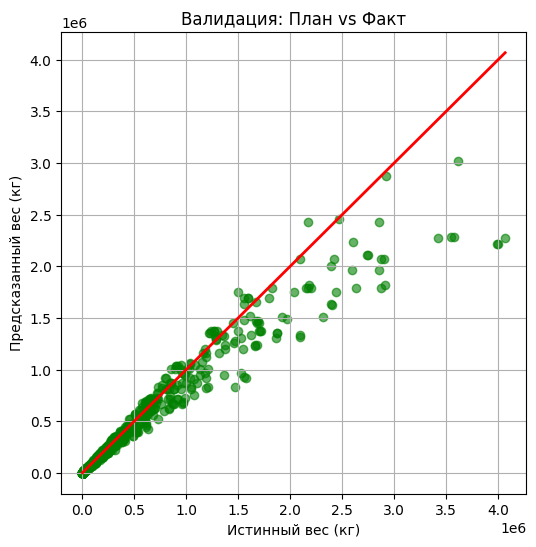


=== Тест (Inference) ===
R²:   0.7144
MAPE: 143.58%
RMSE: 18819.16 кг

=== MAPE по группам на тесте ===
cat
Микро (<2т)        326.66
Средние (2-10т)    109.59
Крупные (>10т)      57.03
Name: MAPE_row, dtype: float64


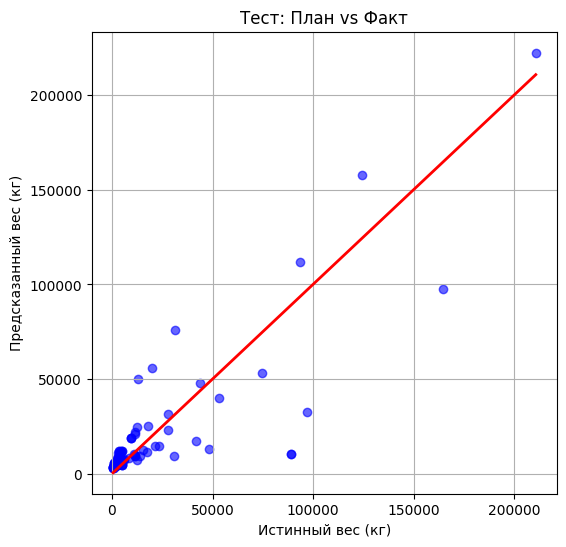


=== Статистика признаков (Train) ===
       liq_volume  diameter  ss_distance  pressure  sk_height  leg_height  \
count     5760.00   5760.00      5760.00   5760.00    5760.00     5760.00   
mean       431.00      2.93        13.91   4310.71       2.84        0.24   
std       1030.70      3.05        16.62   6065.73       2.51        0.55   
min          0.20      0.30         0.60   -100.00       0.00        0.00   
25%          1.96      1.00         3.00    550.00       1.25        0.00   
50%         10.57      1.75         7.00   1966.67       2.50        0.00   
75%        257.38      4.00        15.00   4683.33       4.00        0.00   
max       7696.90     14.00        60.00  22000.00      10.00        2.00   

       p_d_logic  v_ratio  surface_area_proxy_log  volume_proxy_log  
count    5760.00  5760.00                 5760.00           5760.00  
mean        7.98     0.20                    2.60              3.23  
std         1.95     0.07                    1.94         

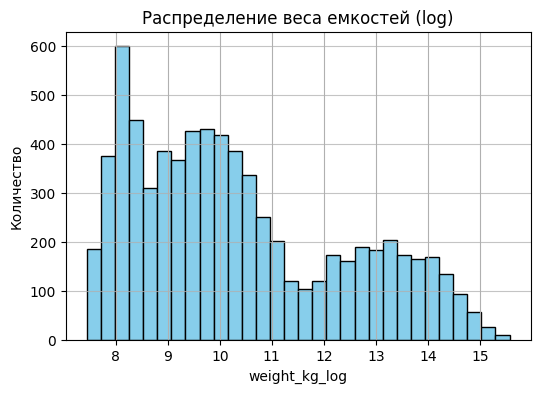


=== Сохранение завершено ===
Файл 'vessel_model_final.joblib' успешно создан.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_squared_error

# --- 1. ФУНКЦИЯ ИНЖИНИРИНГА ПРИЗНАКОВ ---
def engineer_features_final(df):
    X = df.copy()
    # Обработка давления
    X['pressure'] = X['pressure'].fillna(0)
    X['abs_pressure'] = X['pressure'].abs()
    
    # Логарифмический прокси веса стенки (P * D)
    X['p_d_logic'] = np.log1p(X['abs_pressure'] * X['diameter'])
    
    # Коэффициент заполнения
    X['v_ratio'] = X['volume_proxy_log'] - np.log(X['liq_volume'] + 0.1)
    
    feature_cols = [
        "liq_volume", "diameter", "ss_distance", "pressure", 
        "sk_height", "leg_height", "p_d_logic", "v_ratio",
        "surface_area_proxy_log", "volume_proxy_log"
    ]
    return X[feature_cols].fillna(0)

# --- 2. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ---
# --- 2. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ ---
# Добавляем "vessel/" перед названием файла
df_train_full = pd.read_csv("vessel/vessel_dataset_ml.csv")
df_test = pd.read_csv("vessel/vessel_dataset_inference.csv")

# Разделяем обучающую выборку на Train и Val для контроля переобучения
df_train, df_val = train_test_split(df_train_full, test_size=0.2, random_state=42)

X_train = engineer_features_final(df_train)
y_train_log = df_train["weight_kg_log"]

X_val = engineer_features_final(df_val)
y_val_log = df_val["weight_kg_log"]

X_test = engineer_features_final(df_test)
y_test_log = df_test["weight_kg_log"]

# Расчет весов для обучения (агрессивное выравнивание MAPE)
weights = 1.0 / np.exp(y_train_log)
weights = weights / weights.mean()

# --- 3. ОБУЧЕНИЕ МОДЕЛИ ---
model_final = GradientBoostingRegressor(
    loss='absolute_error', 
    n_estimators=1000, 
    learning_rate=0.04, 
    max_depth=5, 
    random_state=42
)

model_final.fit(X_train, y_train_log, sample_weight=weights)

# --- 4. ПРОВЕРКА НА ТРЕНИРОВОЧНЫХ ДАННЫХ (TRAIN) ---
y_pred_train_log = model_final.predict(X_train)
y_train_kg = np.exp(y_train_log)
y_pred_train_kg = np.exp(y_pred_train_log)

print("=== Проверим риски переобучения ===")
print("=== Train ===")
print(f"R²:   {r2_score(y_train_kg, y_pred_train_kg):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_train_kg, y_pred_train_kg) * 100:.2f}%")

# --- 5. ПРОВЕРКА НА ВАЛИДАЦИИ (VAL) ---
y_pred_val_log = model_final.predict(X_val)
y_val_kg = np.exp(y_val_log)
y_pred_val_kg = np.exp(y_pred_val_log)

print("\n=== Val ===")
print(f"R²:   {r2_score(y_val_kg, y_pred_val_kg):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_val_kg, y_pred_val_kg) * 100:.2f}%")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val_kg, y_pred_val_kg)):.2f} кг")

# График валидации
plt.figure(figsize=(6, 6))
plt.scatter(y_val_kg, y_pred_val_kg, alpha=0.6, color='green')
plt.plot([y_val_kg.min(), y_val_kg.max()], [y_val_kg.min(), y_val_kg.max()], color="red", lw=2)
plt.xlabel("Истинный вес (кг)")
plt.ylabel("Предсказанный вес (кг)")
plt.title("Валидация: План vs Факт")
plt.grid(True)
plt.show()

# --- 6. ПРОВЕРКА НА ТЕСТЕ (TEST / INFERENCE) ---
y_pred_test_log = model_final.predict(X_test)
y_test_kg = np.exp(y_test_log)
y_pred_test_kg = np.exp(y_pred_test_log)

print("\n=== Тест (Inference) ===")
print(f"R²:   {r2_score(y_test_kg, y_pred_test_kg):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test_kg, y_pred_test_kg) * 100:.2f}%")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_kg, y_pred_test_kg)):.2f} кг")

# Анализ по категориям на тесте
temp_df = df_test.copy()
temp_df['true_kg'] = y_test_kg
temp_df['pred_kg'] = y_pred_test_kg
temp_df['MAPE_row'] = np.abs((temp_df['true_kg'] - temp_df['pred_kg']) / temp_df['true_kg']) * 100

bins = [0, 2000, 10000, np.inf]
labels = ['Микро (<2т)', 'Средние (2-10т)', 'Крупные (>10т)']
temp_df['cat'] = pd.cut(temp_df['true_kg'], bins=bins, labels=labels)

print("\n=== MAPE по группам на тесте ===")
print(temp_df.groupby('cat', observed=False)['MAPE_row'].mean().round(2))

# График теста
plt.figure(figsize=(6, 6))
plt.scatter(y_test_kg, y_pred_test_kg, alpha=0.6, color='blue')
plt.plot([y_test_kg.min(), y_test_kg.max()], [y_test_kg.min(), y_test_kg.max()], color="red", lw=2)
plt.xlabel("Истинный вес (кг)")
plt.ylabel("Предсказанный вес (кг)")
plt.title("Тест: План vs Факт")
plt.grid(True)
plt.show()

# --- 7. СТАТИСТИКА И РАСПРЕДЕЛЕНИЯ ---
print("\n=== Статистика признаков (Train) ===")
print(X_train.describe().round(2))

print("\n=== Распределение целевой переменной (Log Weight) ===")
plt.figure(figsize=(6, 4))
df_train_full["weight_kg_log"].hist(bins=30, color='skyblue', edgecolor='black')
plt.xlabel("weight_kg_log")
plt.ylabel("Количество")
plt.title("Распределение веса емкостей (log)")
plt.grid(axis='y', alpha=0.75)
plt.show()

# --- 8. СОХРАНЕНИЕ ---
joblib.dump(model_final, "vessel_model_final.joblib")
print("\n=== Сохранение завершено ===")
print("Файл 'vessel_model_final.joblib' успешно создан.")